In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
df = pd.read_csv('airlines.csv', sep=',')

In [66]:
df.head(2)

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0


In [67]:
df.shape

(539382, 8)

In [68]:
df.isnull().sum()

Flight         0
Time           0
Length         0
Airline        0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Class          0
dtype: int64

In [69]:
df[df.duplicated()]

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
373,4532.0,660.0,95.0,MQ,BNA,DCA,3,0
472,3304.0,1175.0,50.0,MQ,GRK,DFW,1,0
486,31.0,1410.0,344.0,US,OGG,PHX,7,0
940,4653.0,1053.0,145.0,OO,FAR,SLC,4,0
969,3784.0,1185.0,78.0,9E,MEM,COU,3,0
...,...,...,...,...,...,...,...,...
539374,1460.0,933.0,158.0,FL,MCO,MDW,3,1
539376,1740.0,652.0,83.0,DL,LAS,SLC,4,1
539378,1264.0,560.0,115.0,WN,LAS,DEN,4,1
539380,607.0,715.0,65.0,WN,BWI,BUF,4,1


In [70]:
#identificando colunas que contem valores duplicados
duplicated_col = []
for col in df.columns:
    if df[col].duplicated().any():
        duplicated_col.append(col)
print(duplicated_col)

['Flight', 'Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Class']


In [71]:
df.describe()

,Flight,Time,Length,DayOfWeek,Class
count,539382.000000,539382.000000,539382.000000,539382.000000,539382.000000
mean,2427.927988,802.728161,132.202104,3.929666,0.445443
std,2067.431700,278.045546,70.117045,1.914666,0.497015
min,1.000000,10.000000,0.000000,1.000000,0.000000
25%,712.000000,565.000000,81.000000,2.000000,0.000000
50%,1809.000000,795.000000,115.000000,4.000000,0.000000
75%,3745.000000,1035.000000,162.000000,5.000000,1.000000
max,7814.000000,1439.000000,655.000000,7.000000,1.000000


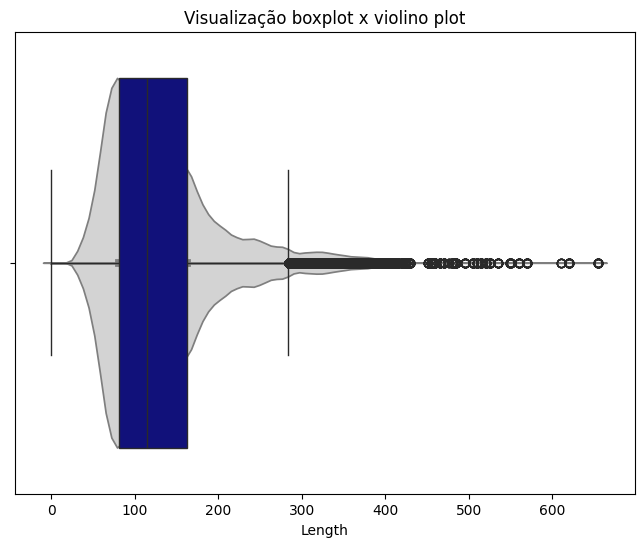

In [72]:
fig, ax = plt.subplots(figsize=(8,6))

sns.violinplot(x='Length', data=df, ax=ax, color='lightgray')

sns.boxplot(x='Length', data=df, ax=ax, whis=1.5, color='darkblue')

ax.set_title('Visualização boxplot x violino plot')

plt.show()

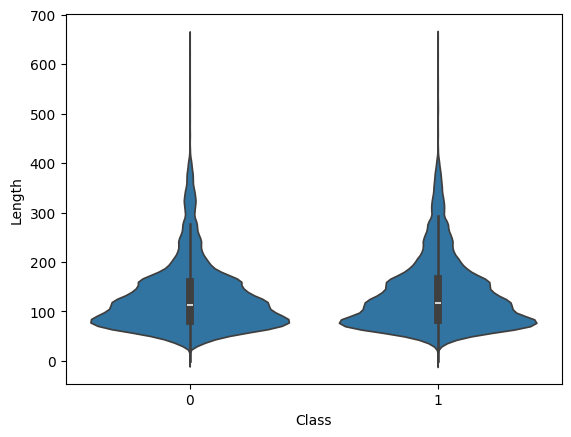

In [73]:
#analise duração dos voos, separador por atraso ou nao atrasso
sns.violinplot(x='Class', y='Length', data=df)
plt.show()

In [74]:
#describe agrupado por atraso e nao atraso
analise_por_clase = df.groupby('Class')
analise_por_clase.describe().T

Class                        0              1
Flight    count  299118.000000  240264.000000
          mean     2513.484842    2321.413508
          std      2102.883185    2017.368082
          min         1.000000       1.000000
          25%       725.000000     701.000000
          50%      1924.000000    1695.000000
          75%      3931.000000    3408.000000
          max      7812.000000    7814.000000
Time      count  299118.000000  240264.000000
          mean      765.235138     849.405308
          std       283.712464     263.472137
          min        10.000000      10.000000
          25%       515.000000     640.000000
          50%       735.000000     860.000000
          75%       998.000000    1060.000000
          max      1439.000000    1439.000000
Length    count  299118.000000  240264.000000
          mean      129.657760     135.369697
          std        68.693953      71.723475
          min         0.000000       0.000000
          25%        81.000000      82.000000
          50%       114.000000     118.000000
          75%       159.000000     166.000000
          max       655.000000     655.000000
DayOfWeek count  299118.000000  240264.000000
          mean        3.974622       3.873697
          std         1.907565       1.922004
          min         1.000000       1.000000
          25%         2.000000       2.000000
          50%         4.000000       4.000000
          75%         5.000000       5.000000
          max         7.000000       7.000000

<Axes: xlabel='Class', ylabel='Time'>

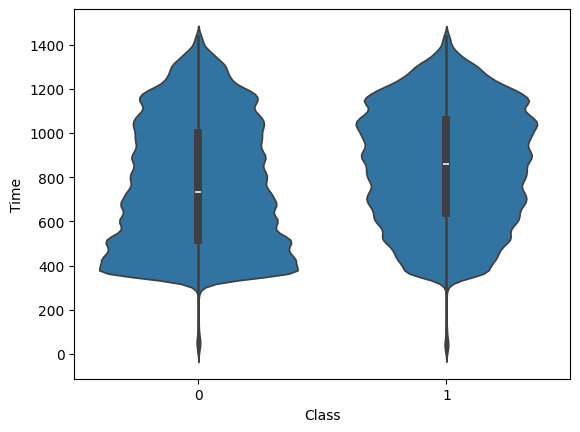

In [75]:
# distribuição do tempo dos voos atraso e nao atraso
sns.violinplot(x='Class', y='Time', data=df)

<Axes: xlabel='Airline', ylabel='count'>

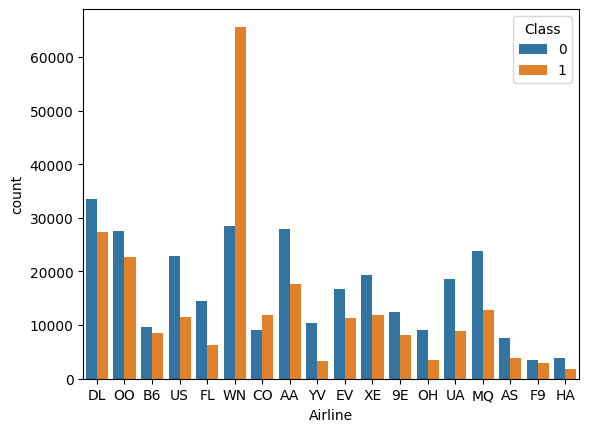

In [76]:
#verificando quais companhias aéreas tem mais atrasos
sns.countplot(x='Airline', hue='Class', data=df)

<Axes: xlabel='DayOfWeek', ylabel='count'>

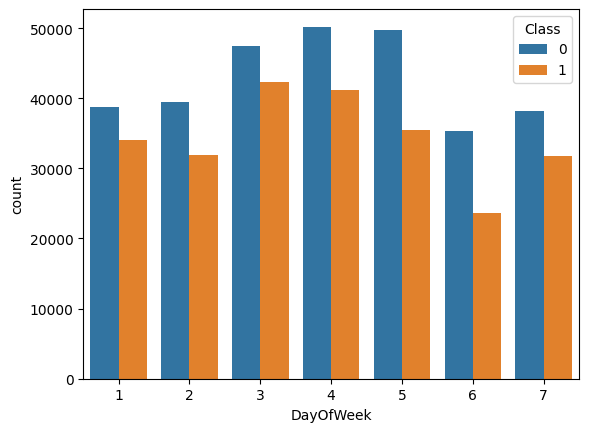

In [77]:
#verificando qual dia da semana tem mais atrasdo
diasemana= list(range(1,8))
sns.countplot(x='DayOfWeek', data=df, hue='Class', order=diasemana)

In [78]:
from sklearn.preprocessing import LabelEncoder

In [79]:
df['AirportFrom']=LabelEncoder().fit_transform(df['AirportFrom'])
df['AirportTo']=LabelEncoder().fit_transform(df['AirportTo'])
df['Airline']=LabelEncoder().fit_transform(df['Airline'])

In [80]:
df.head()

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,5,16,129,1,0
1,6948.0,360.0,146.0,12,65,208,4,0
2,1247.0,1170.0,143.0,3,35,60,3,0
3,31.0,1410.0,344.0,14,203,217,6,0
4,563.0,692.0,98.0,8,32,16,4,0


In [81]:
from sklearn.model_selection import train_test_split

In [82]:
x = df[['Flight', 'Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo','DayOfWeek']]
y = df['Class']

In [104]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=7)

In [105]:
from sklearn.naive_bayes import GaussianNB

In [106]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

GaussianNB()

In [107]:
y_pred = gnb.predict(x_test)

In [87]:
from sklearn.metrics import accuracy_score

In [88]:
accuracy = accuracy_score(y_test,y_pred)
print('Acuracia:', round(accuracy,2))

Acuracia: 0.59


In [89]:
from sklearn.utils import resample

In [90]:
df_majority = df[df.Class == 0]
df_minority = df[df.Class == 1]

In [91]:
df_minority_upsampled = resample(df_minority, replace=True,n_samples=len(df_majority), random_state=7)


In [92]:
df_equilibrado = pd.concat([df_majority, df_minority_upsampled])

<Axes: xlabel='Class', ylabel='count'>

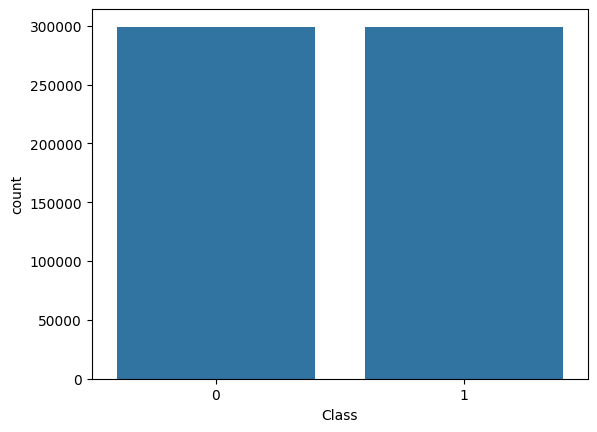

In [93]:
sns.countplot(x='Class', data=df_equilibrado)

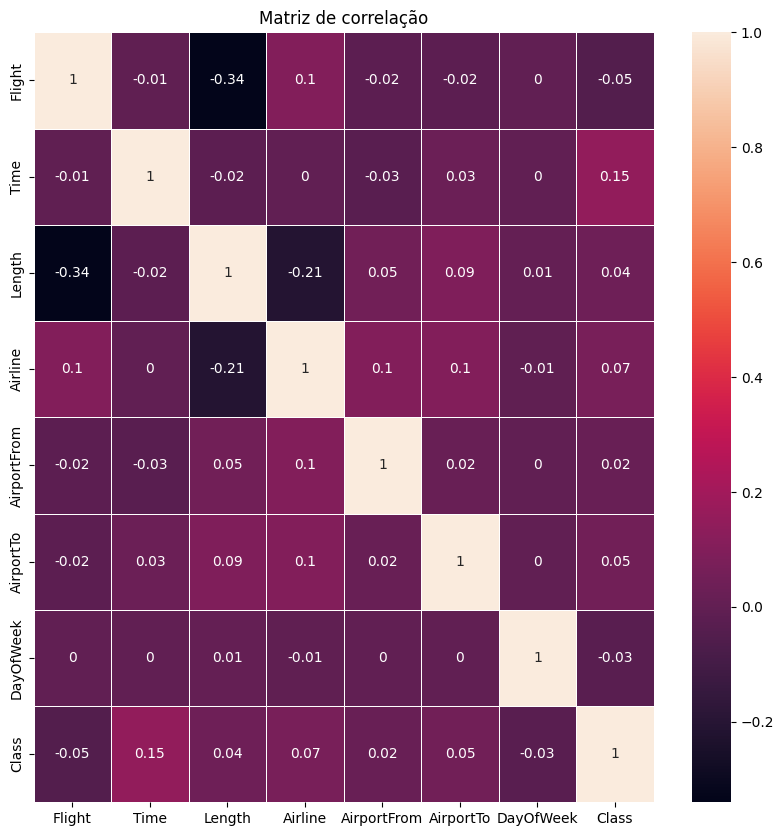

In [94]:
correlacao_dados = df.corr().round(2)

fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(data=correlacao_dados, annot=True, linewidths=.5, ax=ax)
plt.title('Matriz de correlação')
plt.show()

In [111]:
x_equilibrado = df_equilibrado[['Flight', 'Time', 'Length', 'DayOfWeek']]
y_equilibrado = df_equilibrado['Class']

In [121]:
x_train, x_test, y_train, y_test = train_test_split(x_equilibrado, y_equilibrado, test_size=0.3, random_state=7,
                                                     stratify=y_equilibrado)

In [122]:
gnb_equilibrado = GaussianNB()
gnb_equilibrado.fit(x_train, y_train)

GaussianNB()

In [123]:
y_pred_gnb_equiliberado = gnb_equilibrado.predict(x_test)

In [124]:
accuracy_equilibrado = accuracy_score(y_test, y_pred_gnb_equiliberado)

In [125]:
print('Acuracia com df equilibrado:', accuracy_equilibrado)

Acuracia com df equilibrado: 0.5731622379103031


In [126]:
from sklearn.ensemble import RandomForestClassifier

In [127]:
x_train, x_test, y_train, y_test = train_test_split(x_equilibrado, y_equilibrado, test_size=0.3, random_state=7)

In [129]:
rf = RandomForestClassifier(random_state=7)

In [130]:
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=7)

In [131]:
y_pred = rf.predict(x_test)

In [132]:
accuracy_equilibrado = accuracy_score(y_test, y_pred)
print('acuracia do randomforest:', accuracy_equilibrado )

acuracia do randomforest: 0.6925742877679403
